# Customer Segmentation Analysis using K-Means Clustering

### Oasis Infobyte Internship (OIBSIP)

**Domain:** Data Analytics

**Task Level:** Level 1

**Task:** Customer Segmentation Analysis

**Submitted by:** **S Pandi Durai**

## 1. Introduction

Customer Segmentation is the process of dividing customers into groups based on similar characteristics and purchasing behavior. It enables businesses to better understand customer behavior, personalize marketing strategies, improve customer satisfaction, and increase profitability.

In this project, the Mall Customer Segmentation dataset is analyzed using Exploratory Data Analysis (EDA) and the K-Means Clustering algorithm. The objective is to identify distinct customer groups based on their annual income and spending behavior, providing valuable business insights for targeted marketing and customer relationship management.

## 2. Import Required Libraries

The following libraries are imported for data manipulation, data visualization, and machine learning.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (8,5)

## 3. Load the Dataset

The dataset is loaded into a Pandas DataFrame to begin the exploratory data analysis and customer segmentation process.

In [22]:
df = pd.read_csv("dataset.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 4. Dataset Overview

Before performing any analysis, it is important to understand the structure of the dataset. This includes checking the number of rows and columns, data types, missing values, and duplicate records.

In [23]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape of Dataset: (200, 5)

Column Names:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Data Types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


## 5. Data Quality Assessment

Data quality assessment is performed to identify missing values and duplicate records in the dataset. Ensuring clean and complete data is an essential preprocessing step before performing exploratory data analysis and applying machine learning algorithms.

In [24]:
print("Missing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())

Missing Values:

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate Records: 0


## 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps understand the characteristics and distribution of the dataset. It provides valuable insights into customer demographics and purchasing behavior before applying clustering algorithms.

The following analyses are performed:

- Gender Distribution
- Age Distribution
- Annual Income Distribution
- Spending Score Distribution

### 6.1 Gender Distribution

This analysis examines the distribution of customers based on gender. Understanding the gender composition helps identify whether the customer base is balanced or dominated by a particular gender.

A count plot is used because gender is a categorical variable.

Gender
Female    112
Male       88
Name: count, dtype: int64


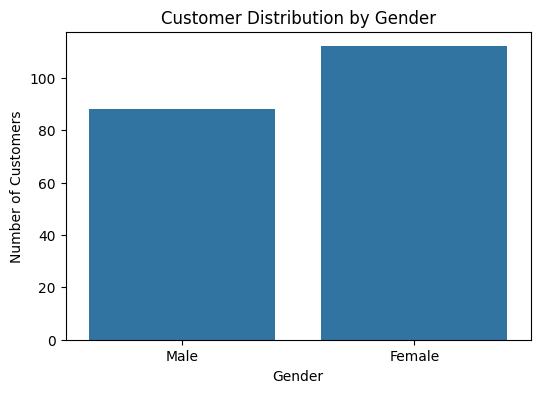

In [25]:
print(df["Gender"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Gender")

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### 6.2 Age Distribution

This analysis examines the age distribution of customers. Understanding customer age helps identify the dominant age groups and provides insights into the target audience of the business.

A histogram is used because age is a continuous numerical variable.

count    200.000000
mean      38.850000
std       13.969007
min       18.000000
25%       28.750000
50%       36.000000
75%       49.000000
max       70.000000
Name: Age, dtype: float64


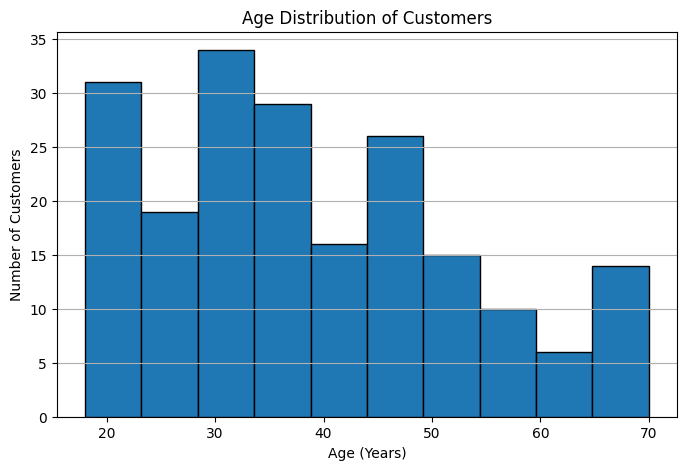

In [26]:
print(df["Age"].describe())

plt.figure(figsize=(8,5))

plt.hist(
    df["Age"],
    bins=10,
    edgecolor="black"
)

plt.title("Age Distribution of Customers")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Customers")

plt.grid(axis="y")

plt.show()

### 6.3 Annual Income Distribution

This analysis examines the distribution of customers based on their annual income. Understanding income levels helps identify the purchasing capacity of customers and provides an important feature for customer segmentation.

A histogram is used because annual income is a continuous numerical variable.

count    200.000000
mean      60.560000
std       26.264721
min       15.000000
25%       41.500000
50%       61.500000
75%       78.000000
max      137.000000
Name: Annual Income (k$), dtype: float64


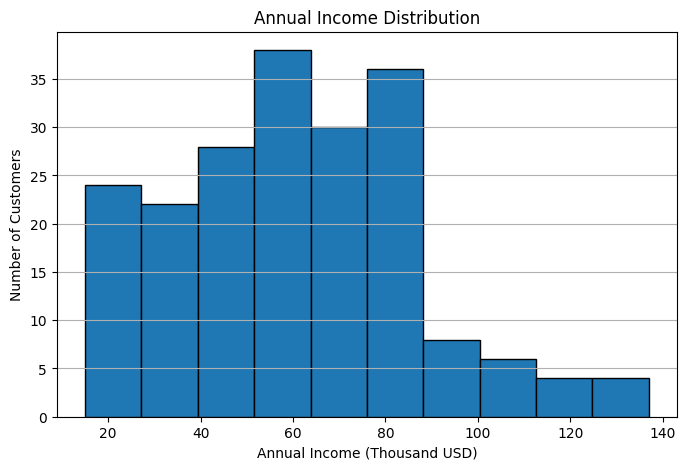

In [27]:
print(df["Annual Income (k$)"].describe())

plt.figure(figsize=(8,5))

plt.hist(
    df["Annual Income (k$)"],
    bins=10,
    edgecolor="black"
)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (Thousand USD)")
plt.ylabel("Number of Customers")

plt.grid(axis="y")

plt.show()

### 6.4 Spending Score Distribution

This analysis examines the distribution of customers based on their spending score. The spending score is assigned by the shopping mall based on customer purchasing behavior and spending habits.

Understanding the distribution of spending scores helps identify customers with low, medium, and high spending behavior. This feature plays a crucial role in customer segmentation using K-Means Clustering.

A histogram is used because spending score is a continuous numerical variable.

count    200.000000
mean      50.200000
std       25.823522
min        1.000000
25%       34.750000
50%       50.000000
75%       73.000000
max       99.000000
Name: Spending Score (1-100), dtype: float64


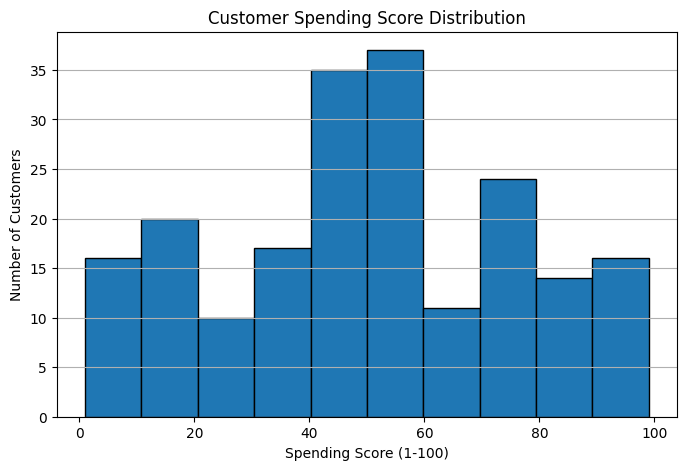

In [28]:
print(df["Spending Score (1-100)"].describe())

plt.figure(figsize=(8,5))

plt.hist(
    df["Spending Score (1-100)"],
    bins=10,
    edgecolor="black"
)

plt.title("Customer Spending Score Distribution")
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Number of Customers")

plt.grid(axis="y")

plt.show()

### 6.5 Relationship Between Annual Income and Spending Score

This analysis examines the relationship between customers' annual income and spending score. These two variables are the primary features used for customer segmentation because they represent purchasing capacity and spending behavior.

A scatter plot is used because both variables are numerical. Each point in the plot represents one customer.

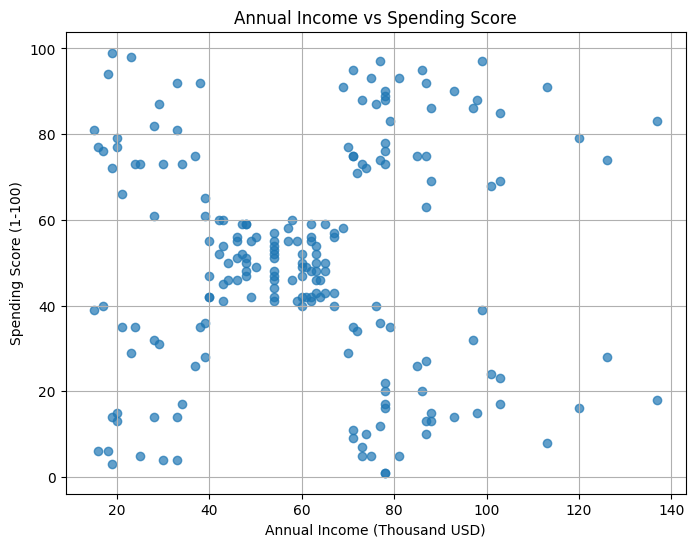

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    alpha=0.7
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (Thousand USD)")
plt.ylabel("Spending Score (1-100)")

plt.grid(True)

plt.show()

### 6.6 Relationship Between Age and Spending Score

This analysis examines the relationship between customer age and spending score. It helps determine whether customers of different age groups exhibit different spending behaviors.

A scatter plot is used because both age and spending score are numerical variables. Each point in the plot represents one customer.

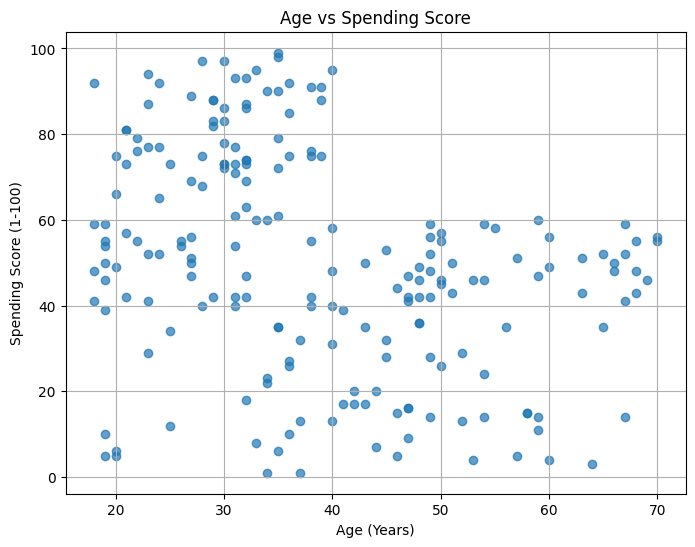

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Age"],
    df["Spending Score (1-100)"],
    alpha=0.7
)

plt.title("Age vs Spending Score")
plt.xlabel("Age (Years)")
plt.ylabel("Spending Score (1-100)")

plt.grid(True)

plt.show()

## 7. Feature Selection

Feature selection is the process of choosing the most relevant variables for building a machine learning model. Selecting appropriate features improves model performance and ensures that clustering is based on meaningful customer characteristics.

For customer segmentation, **Annual Income** and **Spending Score** are selected because they best represent a customer's purchasing capacity and spending behavior.

In [31]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## 8. Feature Scaling

Feature scaling is the process of transforming numerical features so that they have a similar scale. Since K-Means Clustering uses distance to group similar data points, features with larger numerical values can dominate the clustering process.

In this project, **StandardScaler** is used to standardize the selected features before applying the K-Means algorithm.

In [32]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("First 5 Scaled Values:\n")
print(X_scaled[:5])

First 5 Scaled Values:

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


## 9. Elbow Method

The Elbow Method is used to determine the optimal number of clusters (K) for K-Means Clustering. It measures the Within-Cluster Sum of Squares (WCSS), which represents the total distance between data points and their respective cluster centroids.

As the number of clusters increases, WCSS decreases because each cluster becomes smaller. The optimal value of K is selected at the point where the decrease in WCSS starts to slow down significantly, forming an "elbow" in the graph.

In [33]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

print(wcss)

[400.00000000000006, 269.691012192764, 157.7040081503594, 108.92131661364358, 65.56840815571681, 55.057348270386015, 44.86475569922557, 37.228187677585886, 32.39226763033117, 29.981897788243703]


### 9.1 Elbow Curve Visualization

A line chart is used to visualize the relationship between the number of clusters (K) and the Within-Cluster Sum of Squares (WCSS). The optimal number of clusters is identified by locating the "elbow" point where the reduction in WCSS begins to level off.

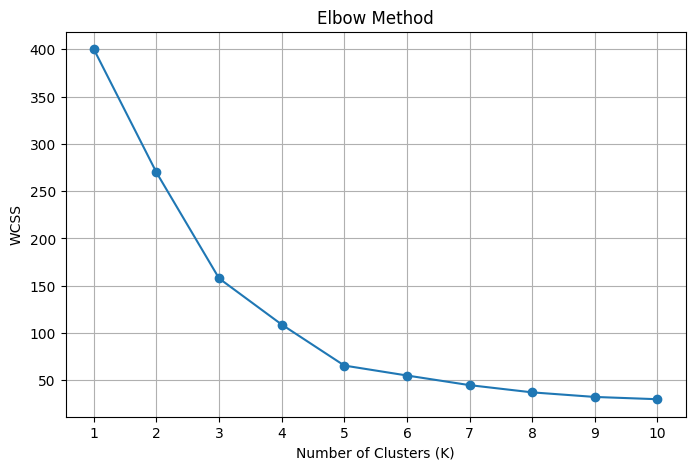

In [34]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.xticks(range(1,11))
plt.grid(True)

plt.show()

## 10. K-Means Clustering

K-Means Clustering is an unsupervised machine learning algorithm that groups similar data points into a predefined number of clusters. Based on the Elbow Method, the optimal number of clusters is selected as **K = 5**.

The algorithm assigns each customer to the nearest cluster centroid based on the similarity of their annual income and spending score.

In [35]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


### 10.1 Customer Cluster Visualization

A scatter plot is used to visualize the customer segments created by the K-Means algorithm. Each color represents a different customer cluster, while the black "X" markers indicate the cluster centroids.

This visualization helps identify distinct customer groups based on annual income and spending score.

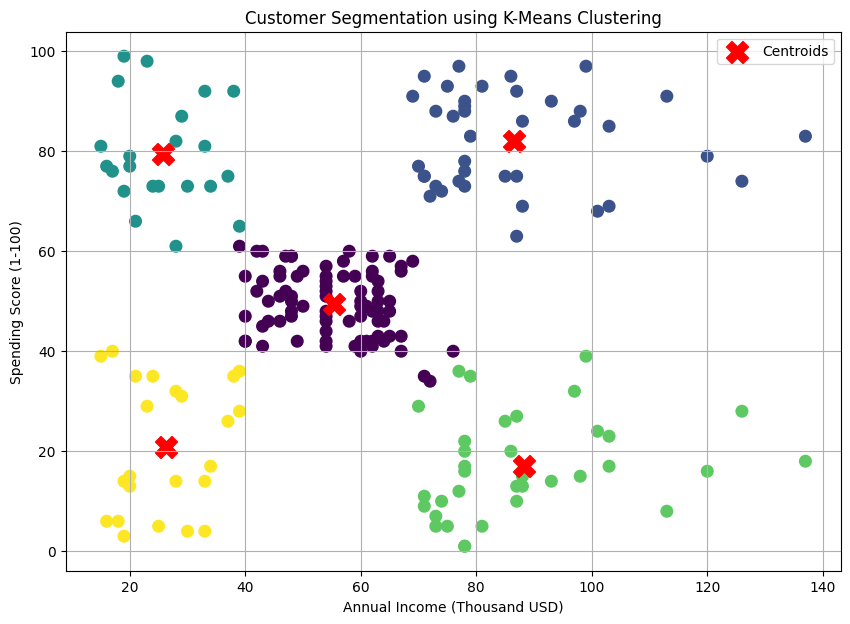

In [36]:
plt.figure(figsize=(10,7))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=clusters,
    cmap="viridis",
    s=70
)

centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    marker="X",
    s=250,
    color="red",
    label="Centroids"
)

plt.title("Customer Segmentation using K-Means Clustering")
plt.xlabel("Annual Income (Thousand USD)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)

plt.show()

## 11. Cluster Analysis

After applying K-Means Clustering, each customer is assigned to a cluster. This analysis summarizes the characteristics of each cluster by calculating the average annual income, average spending score, and the number of customers.

These statistics help interpret customer behavior and provide meaningful business labels for each cluster.


In [37]:
cluster_summary = (
    df.groupby("Cluster")
    .agg({
        "Annual Income (k$)": "mean",
        "Spending Score (1-100)": "mean",
        "CustomerID": "count"
    })
    .rename(columns={
        "Annual Income (k$)": "Average Income (k$)",
        "Spending Score (1-100)": "Average Spending Score",
        "CustomerID": "Number of Customers"
    })
)

cluster_summary = cluster_summary.round(2)

print(cluster_summary)

         Average Income (k$)  Average Spending Score  Number of Customers
Cluster                                                                  
0                      55.30                   49.52                   81
1                      86.54                   82.13                   39
2                      25.73                   79.36                   22
3                      88.20                   17.11                   35
4                      26.30                   20.91                   23


### 11.1 Cluster Size Visualization

A bar chart is used to compare the number of customers in each cluster. This helps understand the distribution of customers across different segments and identify the largest and smallest customer groups.

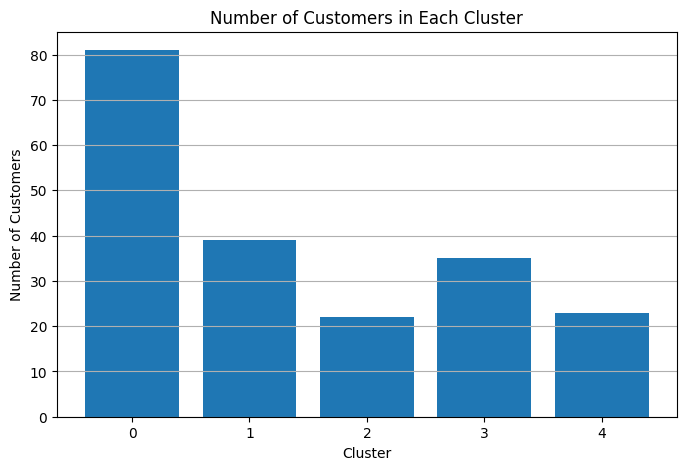

In [38]:
plt.figure(figsize=(8,5))

plt.bar(
    cluster_summary.index.astype(str),
    cluster_summary["Number of Customers"]
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.grid(axis="y")

plt.show()

## 12. Cluster Interpretation

Each cluster represents a unique customer segment based on annual income and spending behavior. By analyzing the average income and spending score of each cluster, meaningful business profiles can be assigned to each customer group.

These customer segments help businesses design targeted marketing strategies and improve customer engagement.

In [39]:
for cluster in sorted(df["Cluster"].unique()):

    print(f"\nCluster {cluster}")

    print("----------------------------------------")

    print("Number of Customers:",
          len(df[df["Cluster"] == cluster]))

    print("Average Age:",
          round(df[df["Cluster"] == cluster]["Age"].mean(),2))

    print("Average Income:",
          round(df[df["Cluster"] == cluster]["Annual Income (k$)"].mean(),2))

    print("Average Spending Score:",
          round(df[df["Cluster"] == cluster]["Spending Score (1-100)"].mean(),2))


Cluster 0
----------------------------------------
Number of Customers: 81
Average Age: 42.72
Average Income: 55.3
Average Spending Score: 49.52

Cluster 1
----------------------------------------
Number of Customers: 39
Average Age: 32.69
Average Income: 86.54
Average Spending Score: 82.13

Cluster 2
----------------------------------------
Number of Customers: 22
Average Age: 25.27
Average Income: 25.73
Average Spending Score: 79.36

Cluster 3
----------------------------------------
Number of Customers: 35
Average Age: 41.11
Average Income: 88.2
Average Spending Score: 17.11

Cluster 4
----------------------------------------
Number of Customers: 23
Average Age: 45.22
Average Income: 26.3
Average Spending Score: 20.91


### 12.1 Business Interpretation

Based on the clustering results, the five customer segments can be interpreted as follows:

| Cluster | Customer Segment | Interpretation |
|---------|------------------|----------------|
| **Cluster 0** | Average Income – Average Spending | Customers with moderate income and balanced spending behavior. They represent the largest customer segment and contribute consistently to business revenue. |
| **Cluster 1** | High Income – High Spending | Premium customers with high purchasing power and high spending behavior. These are the most valuable customers and should be retained through loyalty programs and exclusive offers. |
| **Cluster 2** | Low Income – High Spending | Customers with relatively low income but high spending behavior. They are highly engaged shoppers and can be retained through reward programs and affordable promotional offers. |
| **Cluster 3** | High Income – Low Spending | Customers with high purchasing power but low spending behavior. They represent an opportunity for targeted marketing campaigns and personalized recommendations to encourage higher spending. |
| **Cluster 4** | Low Income – Low Spending | Budget-conscious customers with limited purchasing power and lower spending behavior. Cost-effective promotional campaigns may increase their engagement. |

These customer segments provide valuable business insights that can help organizations design targeted marketing strategies, improve customer satisfaction, and optimize resource allocation.

## 13. Key Business Insights

The customer segmentation analysis successfully divided customers into **five distinct groups** based on annual income and spending behavior using the K-Means Clustering algorithm.

### Key Findings

- **Cluster 1** represents **High Income – High Spending** customers. These are premium customers who contribute significantly to business revenue and should be prioritized for retention.

- **Cluster 3** consists of **High Income – Low Spending** customers. Although they have strong purchasing power, they currently spend less, making them an ideal target for personalized marketing campaigns.

- **Cluster 2** contains **Low Income – High Spending** customers. Despite lower income levels, they actively spend at the shopping mall and can be retained through loyalty programs and promotional offers.

- **Cluster 4** represents **Low Income – Low Spending** customers. These customers are budget-conscious and may respond better to discounts and value-based promotions.

- **Cluster 0** is the largest customer segment, consisting of customers with **Average Income – Average Spending** behavior. They provide stable and consistent business revenue.

- The clustering results demonstrate that customer spending behavior is not determined solely by income. Customers with similar income levels can exhibit very different spending patterns, highlighting the importance of customer segmentation in business decision-making.

Overall, K-Means Clustering successfully transformed customer data into meaningful customer segments that can support targeted marketing and customer relationship management.

## 14. Business Recommendations

Based on the customer segmentation results, the following business recommendations are proposed:

- **Cluster 1 (High Income – High Spending):** These customers are the most valuable segment. Retain them through VIP memberships, exclusive offers, early access to new products, and premium customer service.

- **Cluster 3 (High Income – Low Spending):** These customers have strong purchasing power but spend relatively less. Personalized product recommendations, targeted promotions, and loyalty rewards can encourage higher spending.

- **Cluster 2 (Low Income – High Spending):** These customers demonstrate strong purchasing behavior despite lower income levels. Reward programs, seasonal discounts, and affordable product bundles can help maintain their engagement.

- **Cluster 4 (Low Income – Low Spending):** These customers are budget-conscious shoppers. Cost-effective promotions, discounts on essential products, and value-for-money offers may encourage more frequent purchases.

- **Cluster 0 (Average Income – Average Spending):** This stable customer group contributes consistently to overall sales. Regular engagement through promotional campaigns and personalized recommendations can help improve customer retention and gradually increase spending.

- Businesses should continuously monitor customer purchasing behavior because customer segments may change over time. Periodic customer segmentation can help organizations adapt their marketing strategies and improve customer satisfaction.

- Customer segmentation should be integrated into marketing decision-making to ensure that promotional campaigns are personalized rather than applying the same strategy to all customers.

## 15. Conclusion

This project applied Exploratory Data Analysis (EDA) and the K-Means Clustering algorithm to perform customer segmentation using the Mall Customer Segmentation dataset.

The analysis explored customer demographics, annual income, and spending behavior before selecting the most relevant features for clustering. Feature scaling was applied using StandardScaler, and the Elbow Method was used to determine the optimal number of clusters. The K-Means algorithm successfully grouped customers into five distinct segments based on their purchasing behavior.

The results revealed five meaningful customer groups: **High Income – High Spending**, **High Income – Low Spending**, **Low Income – High Spending**, **Low Income – Low Spending**, and **Average Income – Average Spending**. These customer segments provide valuable insights that enable businesses to design personalized marketing strategies, improve customer engagement, increase customer retention, and optimize marketing investments.

Overall, this project demonstrates how unsupervised machine learning can transform customer data into actionable business insights and support data-driven decision-making.